In [1]:
# temporary notebook for plotting the distribution of phyloP scores between promoters and enhancers

In [2]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

In [11]:
# open promoter phyloP scores
twoFortyWay = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.241.mamm.vcf',
                          sep = '\t',
                          comment = '#',
                          header = None,
                          low_memory = False)
# split out phyloP score
twoFortyWay.loc[:,'phyloP_241'] = [float(i.split('=')[-1]) if i != '.' else '.' for i in twoFortyWay[7]]
# add a groupby id
twoFortyWay.loc[:, 'groupBy_ID'] = [('_').join([chrom, str(pos), idee]) for chrom, pos, idee in zip(twoFortyWay[0], twoFortyWay[1], twoFortyWay[2])]
# groupby position (drop '.'s)
twoFortyWay_groupby = twoFortyWay[twoFortyWay['phyloP_241'] != '.'].filter(['groupBy_ID', 'phyloP_241']).groupby('groupBy_ID').mean().reset_index()

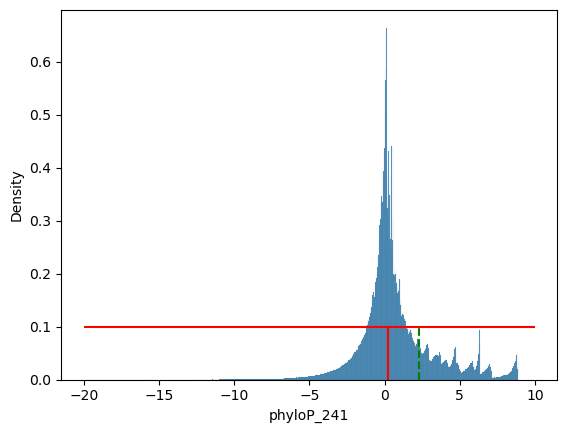

In [24]:
sns.histplot(
    data=twoFortyWay_groupby,
    x='phyloP_241',
    stat='density'
)
plt.vlines(x=twoFortyWay_groupby['phyloP_241'].median(), ymin=0, ymax=0.1, color='red')
plt.hlines(y=0.1, xmin=-20, xmax=10, color='red')
plt.vlines(x=2.27, ymin=0, ymax=0.1, color='green', linestyle='dashed')

In [18]:
twoFortyWay_groupby['phyloP_241'].median()

np.float64(0.254)

In [25]:
# open promoter phyloP scores
fourSeventyWay = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.vcf',
                          sep = '\t',
                          comment = '#',
                          header = None,
                          low_memory = False)
# split out phyloP score
fourSeventyWay.loc[:,'phyloP_470'] = [float(i.split('=')[-1]) if i != '.' else '.' for i in fourSeventyWay[7]]
# add a groupby id
fourSeventyWay.loc[:, 'groupBy_ID'] = [('_').join([chrom, str(pos), idee]) for chrom, pos, idee in zip(fourSeventyWay[0], fourSeventyWay[1], fourSeventyWay[2])]
# groupby position (drop '.'s)
fourSeventyWay_groupby = fourSeventyWay[fourSeventyWay['phyloP_470'] != '.'].filter(['groupBy_ID', 'phyloP_470']).groupby('groupBy_ID').mean().reset_index()

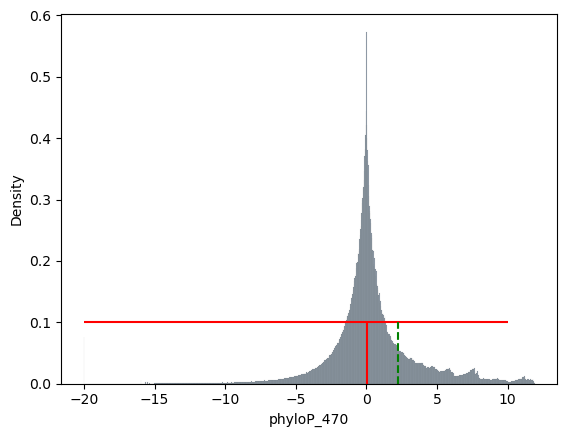

In [27]:
sns.histplot(
    data=fourSeventyWay_groupby,
    x='phyloP_470',
    stat='density',
    color='slategray'
)
plt.vlines(x=fourSeventyWay_groupby['phyloP_470'].median(), ymin=0, ymax=0.1, color='red')
plt.hlines(y=0.1, xmin=-20, xmax=10, color='red')
plt.vlines(x=2.27, ymin=0, ymax=0.1, color='green', linestyle='dashed')

In [28]:
fourSeventyWay_groupby['phyloP_470'].median()

np.float64(0.056)

<Axes: xlabel='phyloP_470', ylabel='Density'>

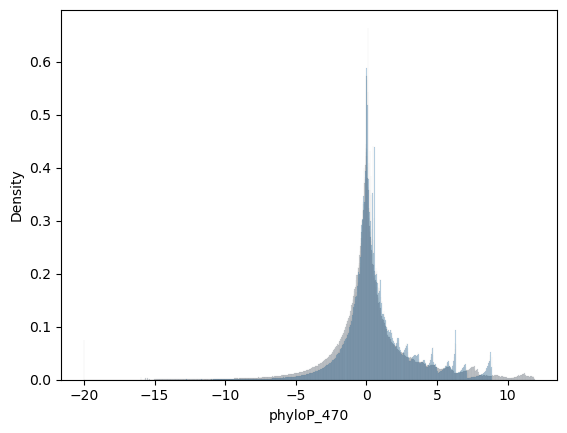

In [30]:
sns.histplot(
    data=fourSeventyWay_groupby,
    x='phyloP_470',
    stat='density',
    color='slategray',
    alpha=0.3
)
sns.histplot(
    data=twoFortyWay_groupby,
    x='phyloP_241',
    stat='density',
    alpha=0.3
)